In [1]:
from cnat_jax import input_pipeline
from cnat_jax import util

from cnat_jax.config import cnat

import plotly.graph_objects as go

2025-07-24 11:04:31.547774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753322671.610568 1707130 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753322671.625641 1707130 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753322671.722297 1707130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753322671.722340 1707130 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753322671.722343 1707130 computation_placer.cc:177] computation placer alr

In [2]:
def show_atoms(pose, title=None, color=None):
    fig = go.Figure()
    fig.add_trace(
        go.Scatter3d(
            x=pose[:, 0],
            y=pose[:, 1],
            z=pose[:, 2],
            mode="markers",
            marker=dict(opacity=0.8),
            showlegend=False,
            text=title,
            marker_color=color,
        )
    )
    fig.update_layout(
        title_text=title,
        height=400,
        width=400,
        scene=dict(
            xaxis=dict(range=[-1, 1], title="x"),
            yaxis=dict(range=[-1, 1], title="y"),
            zaxis=dict(range=[-1, 1], title="z"),
            aspectmode="manual",
            aspectratio=dict(x=1, y=1, z=1),
        ),
        margin=dict(l=0, r=0, b=0, t=50),
    )
    fig.show()

I0000 00:00:1753322680.397217 1707130 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16344 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:ac:00.0, compute capability: 8.6


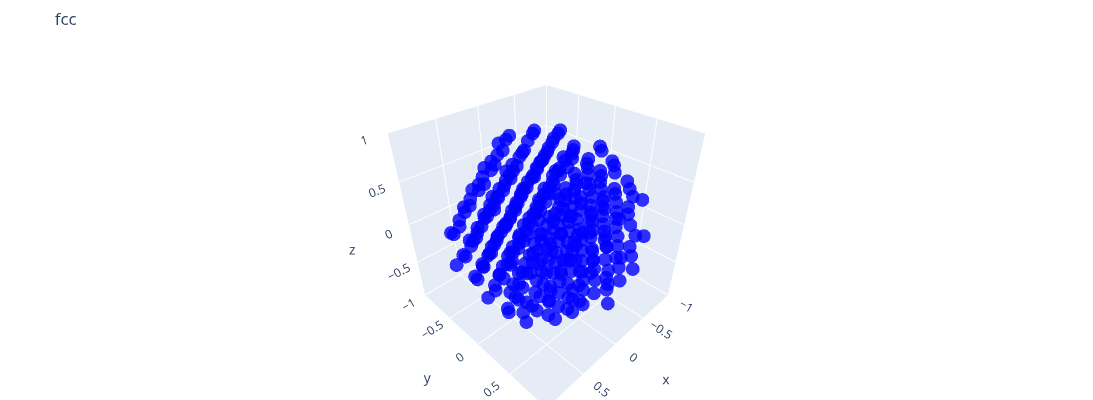

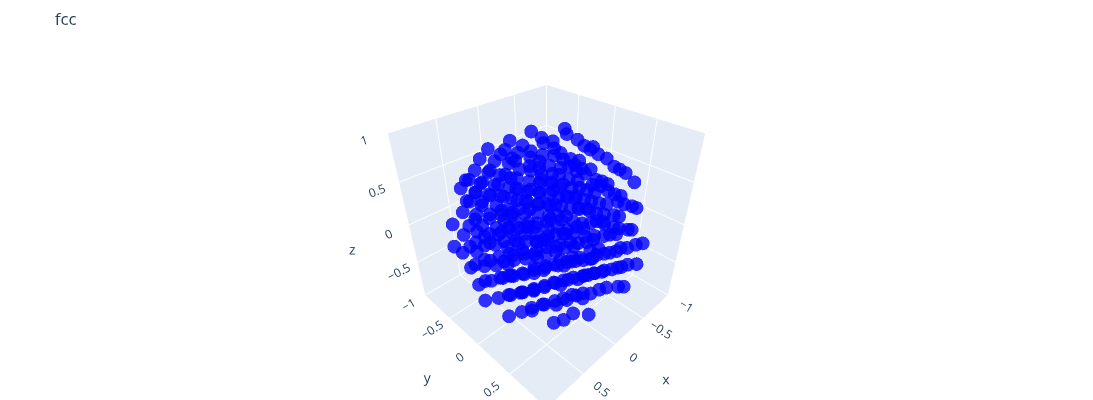

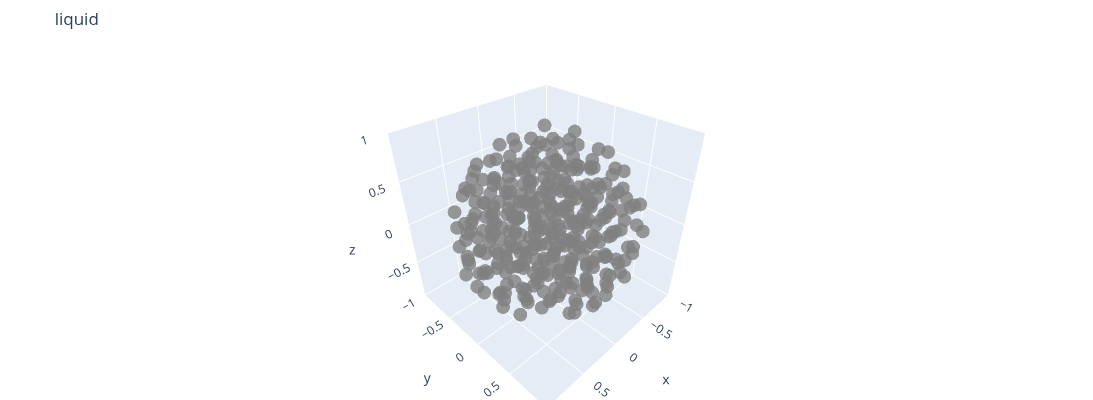

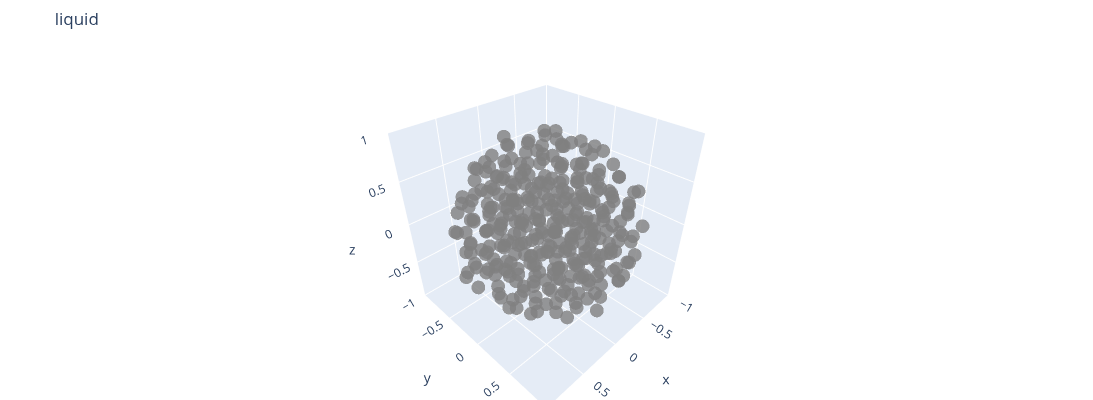

In [3]:
config = cnat.get_config("b15,na_dataset")
ds_train, ds_test = input_pipeline.get_datasets(config)
info = input_pipeline.get_dataset_info(config.dataset, config.pp["train"])

batch = next(iter(ds_train.as_numpy_iterator()))
poses, labels = batch["atoms"][0][:4], batch["label"][0][:4]
phases = map(info["int2str"], labels.argmax(axis=1))
for i, (pose, phase) in enumerate(zip(poses, phases)):
    show_atoms(
        pose,
        title=phase,
        color="blue" if phase == "fcc" else "gray",
    )

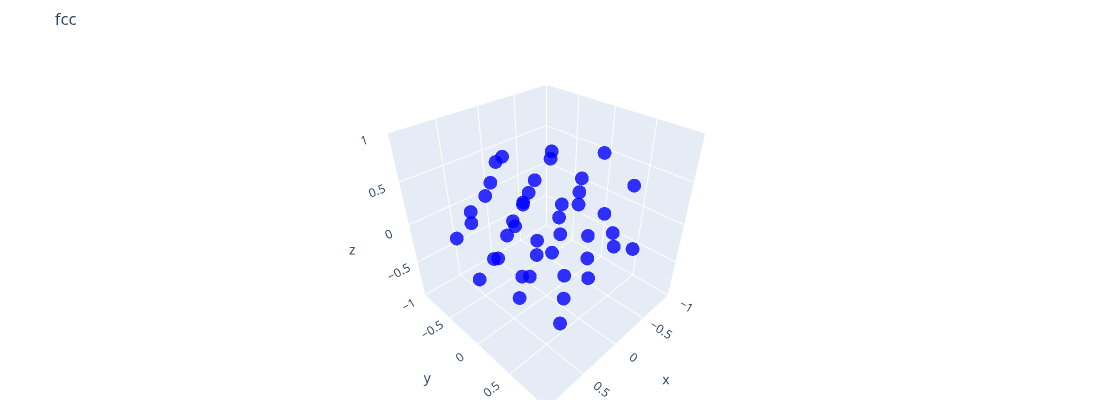

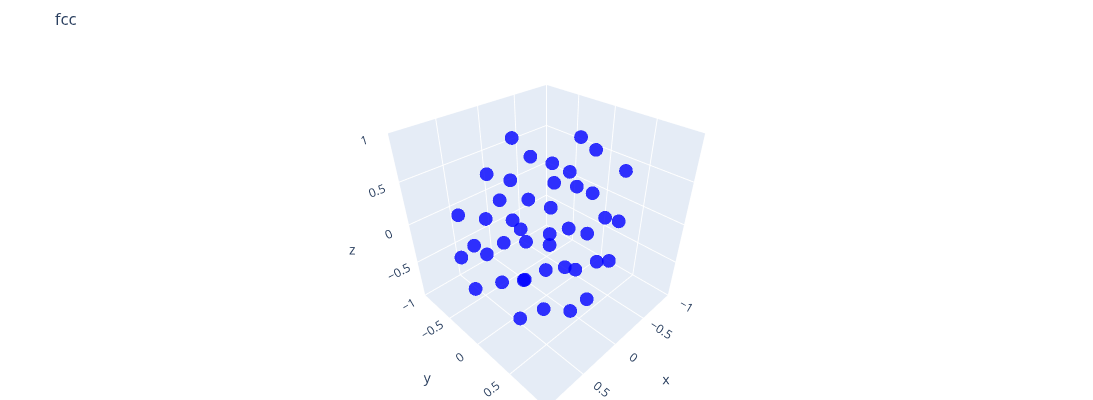

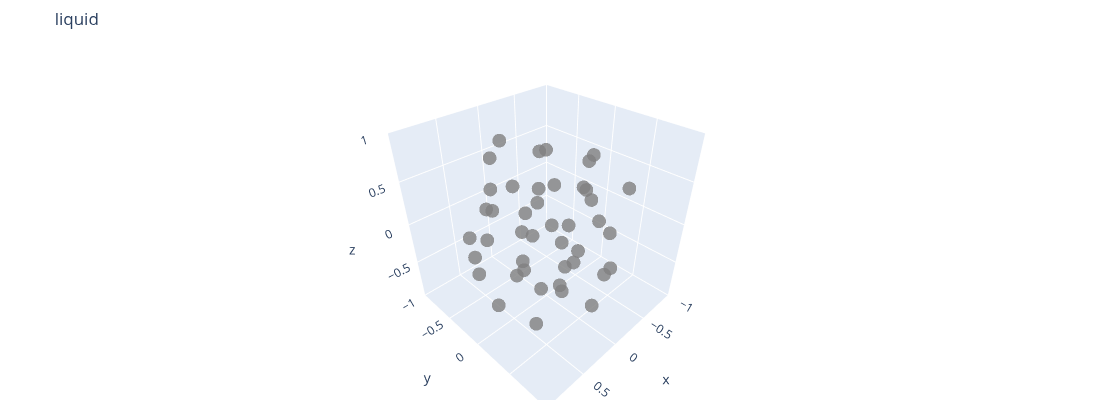

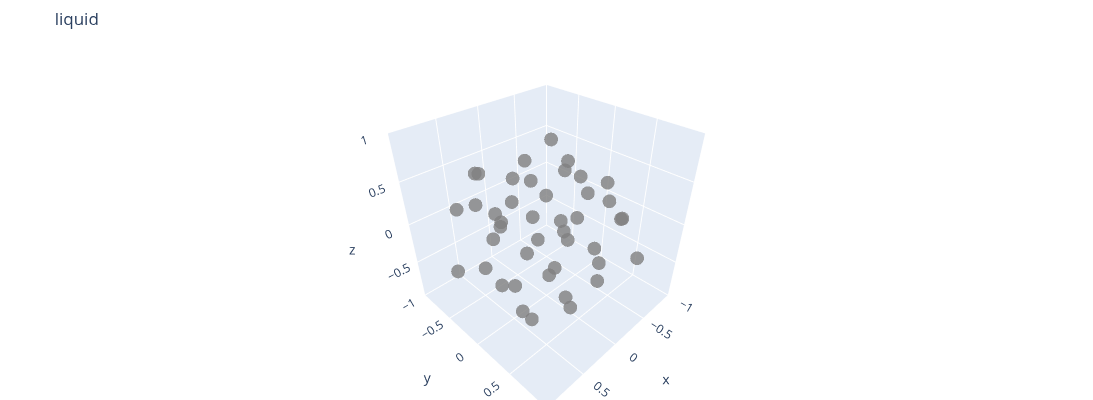

In [4]:
config.num_atoms = 43
ds_train, ds_test = input_pipeline.get_datasets(config)
info = input_pipeline.get_dataset_info(config.dataset, config.pp["train"])

batch = next(iter(ds_train.as_numpy_iterator()))
poses, labels = batch["atoms"][0][:4], batch["label"][0][:4]
phases = map(info["int2str"], labels.argmax(axis=1))
for i, (pose, phase) in enumerate(zip(poses, phases)):
    show_atoms(
        pose,
        title=phase,
        color="blue" if phase == "fcc" else "gray",
    )

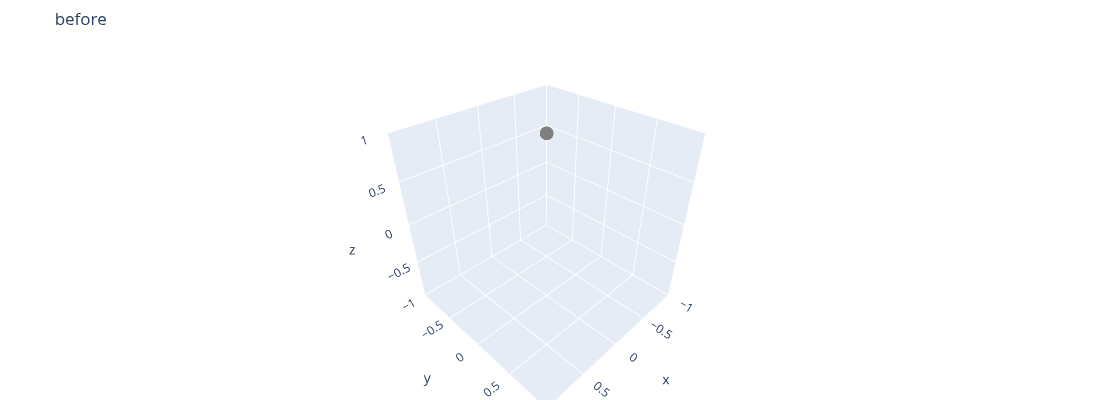

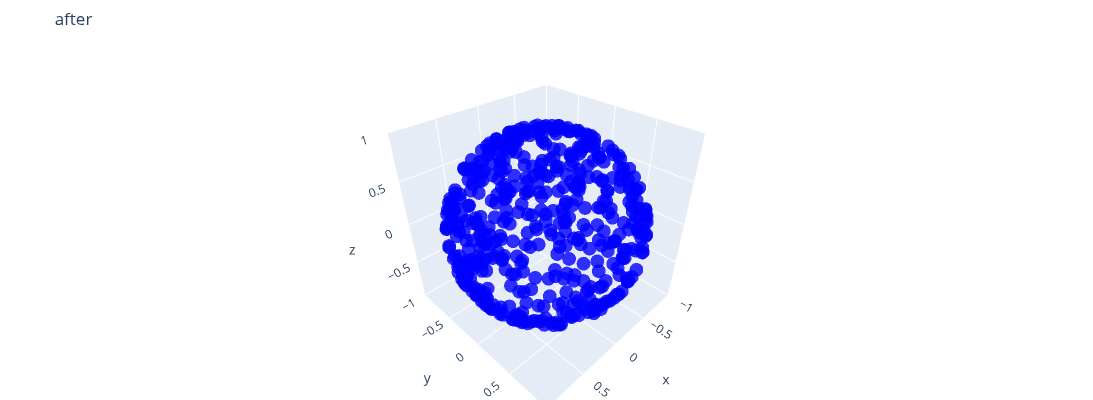

In [5]:
import tensorflow as tf

N = 500
base_points = tf.tile(tf.expand_dims(tf.constant([0.0, 0.0, 1.0]), axis=0), [N, 1])
random_points = tf.map_fn(util.random_rot, base_points)
show_atoms(base_points, "before", "gray")
show_atoms(random_points, "after", "blue")